In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/smartcart_customers.csv')

In [ ]:
# df.head()
df.shape

(2240, 22)

In [ ]:
df.isnull().sum()
# df.dtypes

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [ ]:
# df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


Feature Eng.

In [ ]:
df["Age"] = 2026-df["Year_Birth"]

In [ ]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

# reference_date is based on the latest customer join date

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [ ]:
# print(df["Dt_Customer"].head())

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [ ]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [ ]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [ ]:
# df["Education"].value_counts()

In [ ]:
df["Education"] = df["Education"].replace({
    "Basic": "undergrad",
    "2n Cycle": "undergrad",
    "Graduation": "undergrad",
    "Master": "postgrad",
    "PhD": "postgrad"
})

display(df["Education"].value_counts())

,count
Education,
undergrad,1384
postgrad,856


In [ ]:
# df["Education"].value_counts()

In [ ]:
# df["Marital_Status"].value_counts()

In [ ]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone",
    "Single": "Alone"
})

# display(df["Living_With"].value_counts())

Drop Columns

In [ ]:
# cols_to_drop = [ "ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds" ]

cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [ ]:
df_cleaned.shape

(2240, 15)

In [ ]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,undergrad,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,undergrad,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,undergrad,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,undergrad,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgrad,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


outliers remove


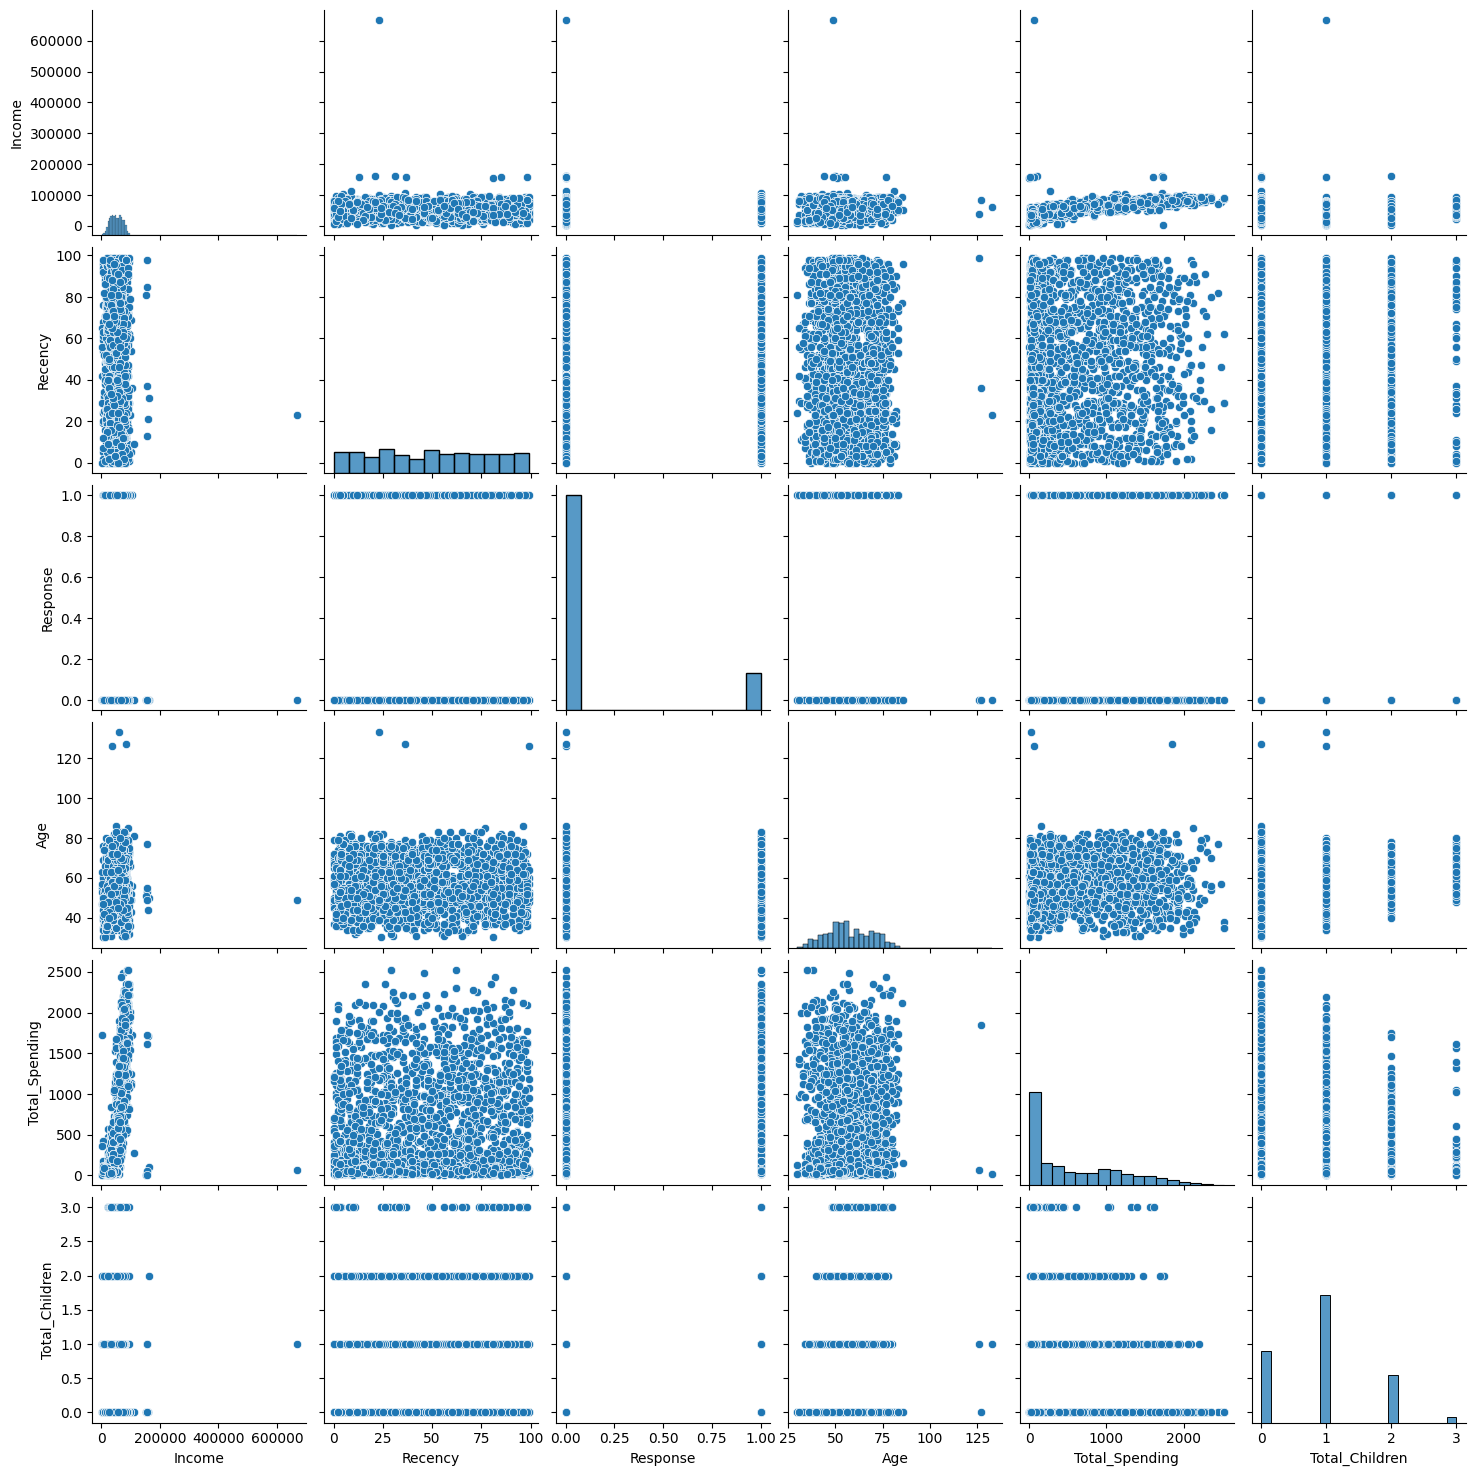

In [ ]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [ ]:
print("data size with outlier" , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outlier" , len(df_cleaned))

data size with outlier 2240
data size without outlier 2236


heatmap

In [ ]:
corr =df_cleaned.corr(numeric_only=True)

<Axes: >

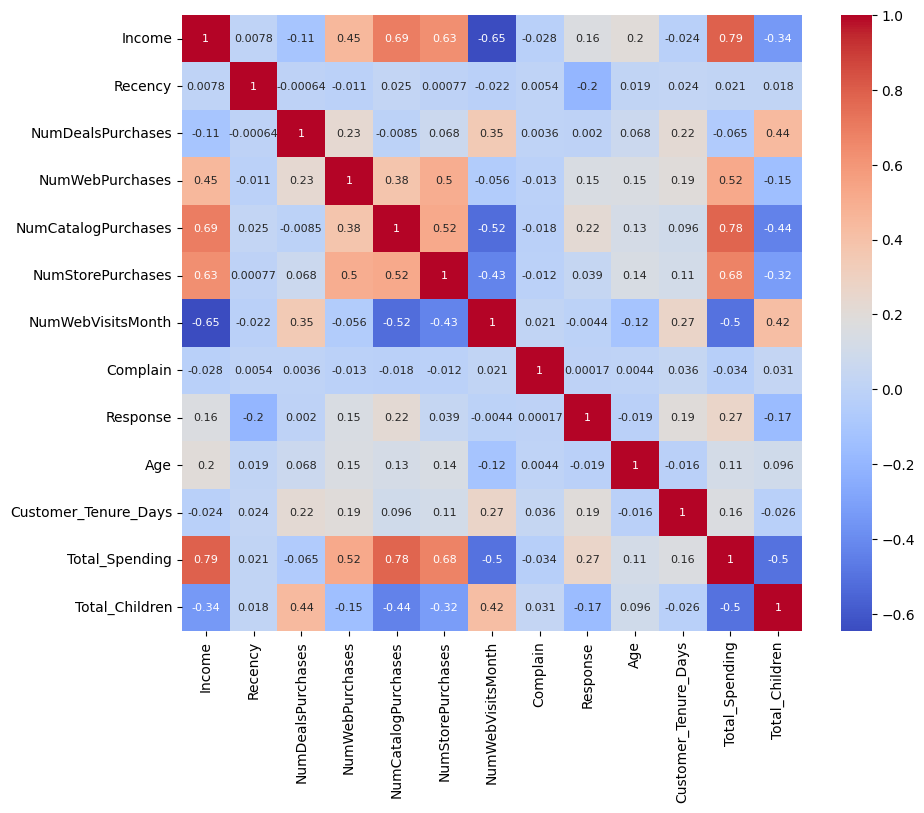

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, annot_kws={"size": 8}, cmap="coolwarm")

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder()  # drop first not used in clustering

cat_cols = ["Education", "Living_With"]

# encoded_cols = pd.DataFrame(ohe.fit_transform(df_cleaned[cat_cols]).toarray())
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [ ]:
enc_df.head()

,Education_postgrad,Education_undergrad,Living_With_Alone,Living_With_Partner
0,0.0,1.0,1.0,0.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,1.0


In [ ]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df] , axis=1)

scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df_encoded

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ...,  0.78683962,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ...,  0.78683962,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ...,  0.78683962,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ...,  0.78683962,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -1.27090703,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -1.27090703,
        -0.74204052,  0.74204052]])

visualize

In [ ]:
# 2D PLOT PRINCIPLE COMPNENT ANALYSIS
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

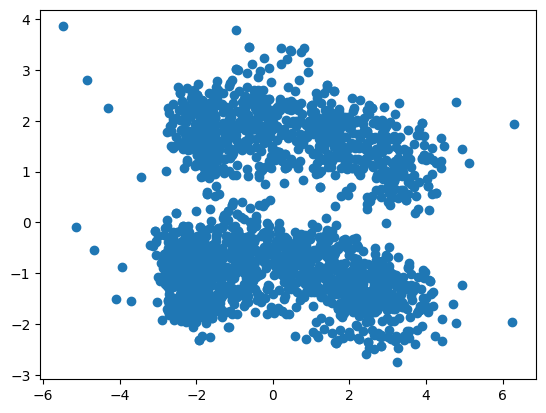

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])


In [ ]:
pca.explained_variance_ratio_

array([0.24458675, 0.12280796, 0.12035147])

Text(0.5, 0.92, '3d projection')

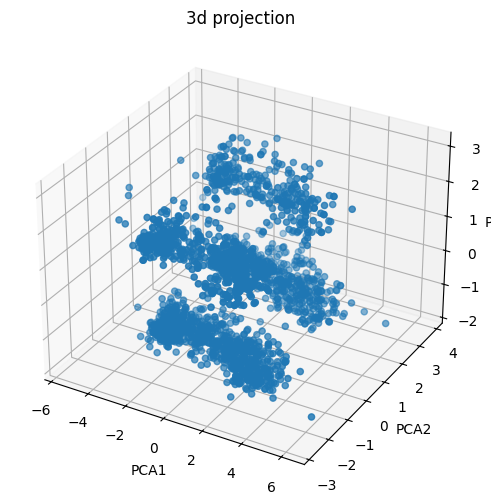

In [ ]:
# plot in 3D
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# **Analyze K value**

In [ ]:
!pip install kneed
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcs=[]
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcs.append(kmeans.inertia_)

In [ ]:
knee = KneeLocator(range(1, 11), wcs, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [ ]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

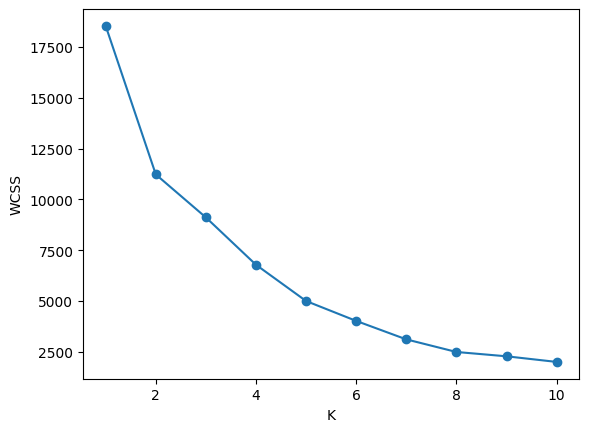

In [ ]:
plt.plot(range(1, 11), wcs, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

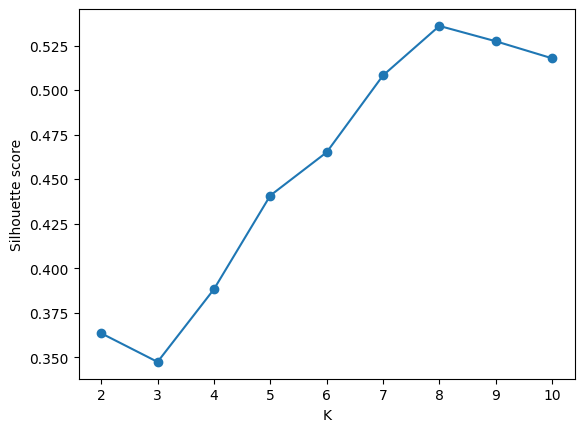

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11): # 1 not considered in silhoutte
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

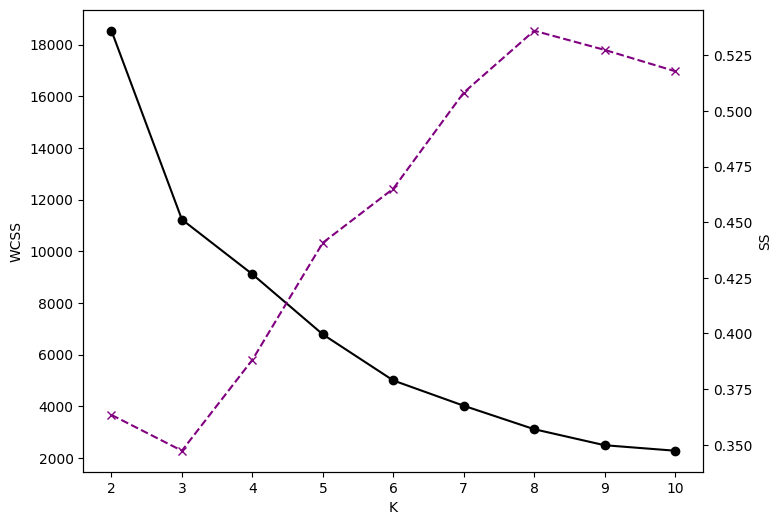

In [ ]:
# combined plot  to get balnced of both

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcs[:len(k_range)], marker="o", color="black")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="purple", linestyle="--")
ax2.set_ylabel("SS")

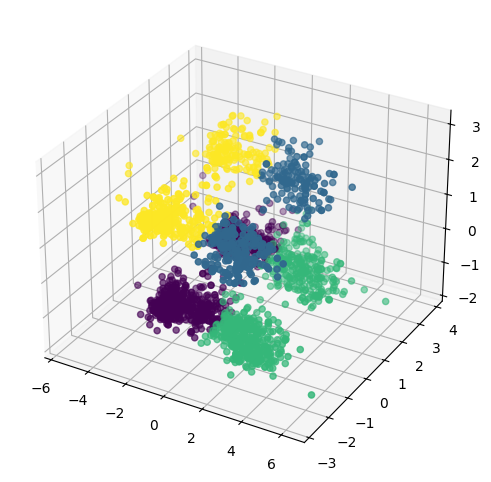

In [ ]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)




#from 3d projection
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

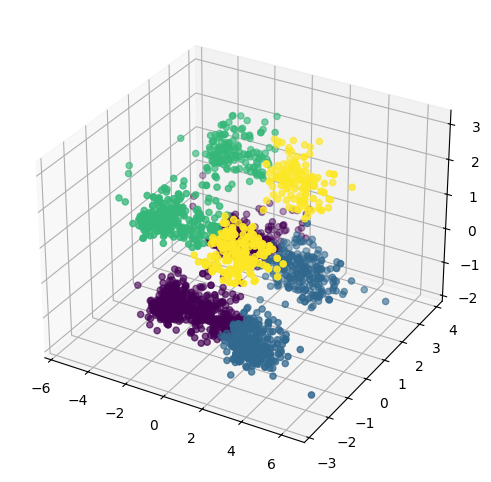

In [ ]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering



agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)




fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

better with anglo and dbscan will create more clusters which will be confusing .

In [ ]:
# 1st
# # df_cleaned["labels"] = labels_agg
# 2nd
# # df_cleaned.drop("labels" , axis=1)
# # df_cleaned["cluster"] = labels_agg
# 3rd

X["cluster"] = labels_agg

In [ ]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,undergrad,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,undergrad,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,undergrad,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,undergrad,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgrad,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


<Axes: xlabel='cluster', ylabel='count'>

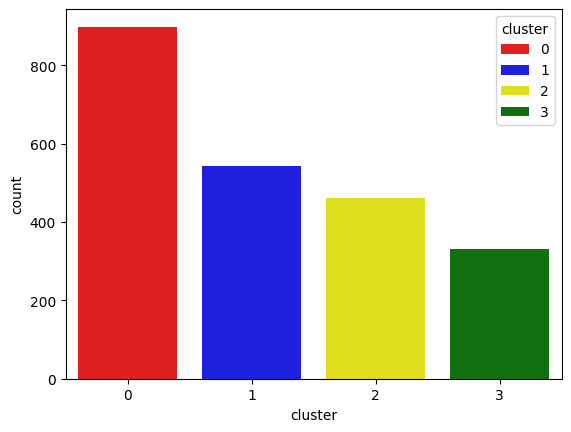

In [ ]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

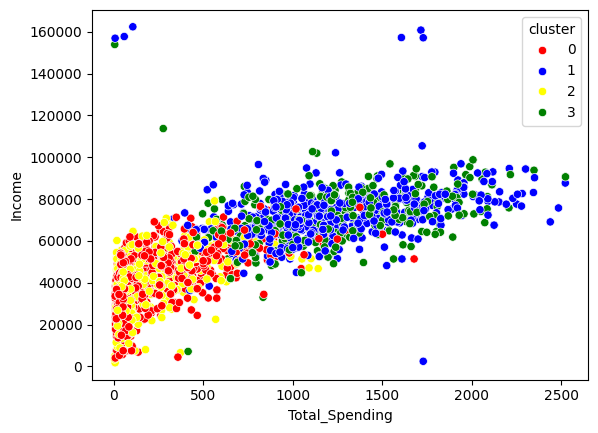

In [ ]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [ ]:
# Cluster Summary
# df_cleaned does not have encoded values thus we will take X instead of it
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39388.086207  49.426029           2.655172         3.145717   
1        72554.790976  48.399632           1.883978         5.642726   
2        38186.538961  48.132035           2.569264         2.850649   
3        71435.912651  50.819277           1.819277         5.816265   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.948832           4.109010           6.400445  0.011123   
1                   5.451197           8.620626           3.545120  0.005525   
2                   0.904762           3.816017           6.521645  0.010823   
3                   5.192771           8.496988           3.617470  0.006024   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         